In [1]:
import sys
!{sys.executable} -m pip install -q 'scanpy[leiden]'


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/bin/python -m pip install --upgrade pip


In [199]:
import scanpy as sc
import scipy as sp
import numpy as np
import anndata as ad
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import ot

In [166]:
n_samples = 300

In [4]:
mouse_adata = sc.read_10x_h5('../data/mouse/5k_Mouse_PBMCs_5p_gem-x_5k_Mouse_PBMCs_5p_gem-x_count_sample_filtered_feature_bc_matrix.h5')

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
# preprocessing mouse
mouse_adata.var_names_make_unique()
sc.pp.filter_cells(mouse_adata, min_genes=100)
sc.pp.filter_genes(mouse_adata, min_cells=3)
mouse_adata.layers["counts"] = mouse_adata.X.copy()
sc.pp.normalize_total(mouse_adata)
sc.pp.log1p(mouse_adata)
sc.pp.highly_variable_genes(mouse_adata, n_top_genes=2000)
sc.tl.pca(mouse_adata)

In [6]:
# labeling cell types on pig
sc.pp.neighbors(mouse_adata)
sc.tl.umap(mouse_adata)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
mouse_adata.obs['leiden']=None

In [8]:
sc.tl.leiden(mouse_adata, flavor="igraph", n_iterations=2, resolution=0.1)

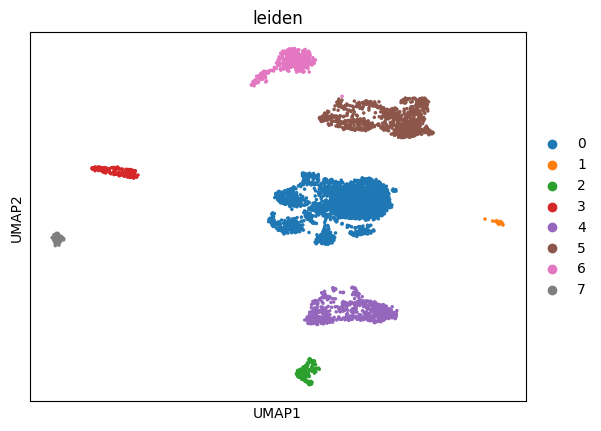

In [9]:
sc.pl.umap(mouse_adata, color=["leiden"])

In [10]:
mouse_marker_genes = {
    "T": ["Cd4", "Cd8a", "Ccr7", "Sell", "Cd3e", "Id2", "Cd44", "Klrb1c", "Gzma"],
    "NK": ["Nkg7"],
    "B": ["Ms4a1","Cd79a"],
    "Mono/DC": ["Cx3cr1", "Ly6c2", "Ccr2", "Csf1r", "Cd209a", "Syngr2"],
    "Megakaryocytes": ["Ppbp", "Pf4", "Gng11"],
    "Macrophages": ["C1qa", "C1qb", "C1qc"],
    "Basophil": ["Fcer1a", "Cd200r3", "Ms4a2"],
    "RBC": ['Hba-a1'],
    "Neutrophil": ["Csf3r","Cxcr2","Ncf4"]
}

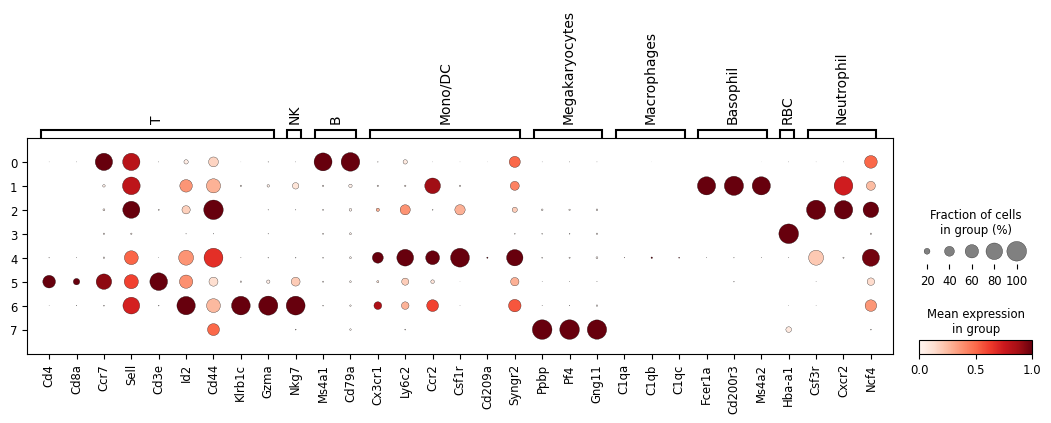

In [11]:
sc.pl.dotplot(mouse_adata, mouse_marker_genes, groupby="leiden", standard_scale="var")

In [209]:
mouse_leiden_cell_types = {"0":"B cell",
                           "1":"basophil",
                           "2":"neutrophil",
                           "3":"erythrocyte",
                           "4":"classical monocyte",
                           "5":"T cell",
                           "6":"natural killer cell",
                           "7":"megakaryocyte"
                          }

In [210]:
mouse_cell_type_labels = [mouse_leiden_cell_types[cluster] for cluster in mouse_adata.obs['leiden']]

In [211]:
mouse_adata.obs['cell_type'] = mouse_cell_type_labels

In [212]:
plt.figure(figsize=(1, 1))

<Figure size 100x100 with 0 Axes>

<Figure size 100x100 with 0 Axes>

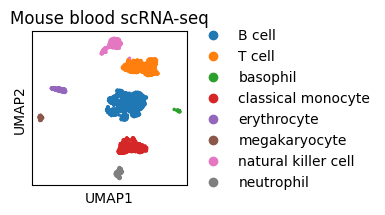

In [216]:
fig, ax = plt.subplots(figsize=(2, 2))
sc.pl.umap(mouse_adata, color='cell_type', ax=ax, show=False, title="Mouse blood scRNA-seq")
plt.show()

AttributeError: PathCollection.set() got an unexpected keyword argument 'figsize'

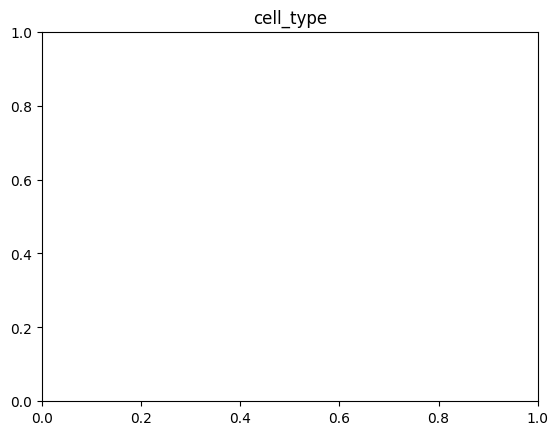

In [207]:
sc.pl.umap(mouse_adata, color=["cell_type"], figsize=(4, 3))

In [40]:
mouse_small = sc.pp.subsample(mouse_adata, n_obs=n_samples, copy=True)

In [164]:
def balanced_sample(adata):
    n_per_cell_type = 50
    b_subsample = sc.pp.sample(adata[adata.obs['cell_type']=="B cell"], n=n_per_cell_type, replace=True, copy=True)
    t_subsample = sc.pp.sample(adata[adata.obs['cell_type']=="T cell"], n=n_per_cell_type, copy=True)
    monocyte_subsample = sc.pp.sample(adata[adata.obs['cell_type']=="classical monocyte"], n=n_per_cell_type, replace=True, copy=True)
    neutrophil_subsample = sc.pp.sample(adata[adata.obs['cell_type']=="neutrophil"], n=n_per_cell_type, replace=True, copy=True)
    nk_subsample = sc.pp.sample(adata[adata.obs['cell_type']=="natural killer cell"], n=n_per_cell_type, replace=True, copy=True)
    rbc_subsample = sc.pp.sample(adata[adata.obs['cell_type']=="erythrocyte"], n=n_per_cell_type, replace=True, copy=True)
    return ad.concat([b_subsample, t_subsample, monocyte_subsample, neutrophil_subsample, nk_subsample, rbc_subsample])

In [165]:
mouse_balanced = balanced_sample(mouse_adata)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Human data

In [20]:
human_adata = sc.read_h5ad('../data/human/tabula_sapiens_pbmc.h5ad')

In [21]:
human_adata.obs['cell_type'] = human_adata.obs['cell_type'].replace({'CD4-positive, alpha-beta T cell':'T cell','CD8-positive, alpha-beta T cell':'T cell'})

/tmp/ipykernel_3557275/219824235.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  human_adata.obs['cell_type'] = human_adata.obs['cell_type'].replace({'CD4-positive, alpha-beta T cell':'T cell','CD8-positive, alpha-beta T cell':'T cell'})


In [59]:
human_adata.obs['donor_id'].value_counts()

donor_id
TSP7     20383
TSP14    20303
TSP21    14103
TSP2     12949
TSP8      4988
TSP1      4448
TSP10     4360
TSP25     3202
TSP27      497
Name: count, dtype: int64

In [22]:
donor_tsp1 = human_adata[human_adata.obs['donor_id']=='TSP1']
donor_tsp1_10x = donor_tsp1[donor_tsp1.obs['method']=='10X']

In [23]:
donor_tsp10 = human_adata[human_adata.obs['donor_id']=='TSP10']
donor_tsp10_10x = donor_tsp10[donor_tsp10.obs['method']=='10X']

In [69]:
donor_tsp2 = human_adata[human_adata.obs['donor_id']=='TSP2']
donor_tsp2_10x = donor_tsp2[donor_tsp2.obs['method']=='10X']

In [193]:
donor_tsp21 = human_adata[human_adata.obs['donor_id']=='TSP21']
donor_tsp21_10x = donor_tsp21[donor_tsp21.obs['method']=='10X']

In [25]:
def preprocess_10x(human_adata):
    human_adata.var_names_make_unique()
    sc.pp.filter_cells(human_adata, min_genes=100)
    sc.pp.filter_genes(human_adata, min_cells=3)
    human_adata.layers["counts"] = human_adata.X.copy()
    sc.pp.normalize_total(human_adata)
    sc.pp.log1p(human_adata)
    sc.pp.highly_variable_genes(human_adata, n_top_genes=2000)
    sc.tl.pca(human_adata)

In [133]:
preprocess_10x(donor_tsp1_10x)
preprocess_10x(donor_tsp10_10x)
preprocess_10x(donor_tsp2_10x)
preprocess_10x(donor_tsp21_10x)

adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.


In [194]:
preprocess_10x(donor_tsp21_10x)

In [27]:
tsp1_small = sc.pp.subsample(donor_tsp1_10x, n_obs=n_samples, copy=True)
tsp10_small = sc.pp.subsample(donor_tsp10_10x, n_obs=n_samples, copy=True)
tsp8_small = sc.pp.subsample(donor_tsp8_10x, n_obs=n_samples, copy=True)

In [192]:
donor_tsp8_10x.obs['cell_type'].value_counts()

cell_type
neutrophil                                              4558
classical monocyte                                       236
B cell                                                    75
T cell                                                    71
natural killer cell                                       14
macrophage                                                10
plasma cell                                               10
naive thymus-derived CD4-positive, alpha-beta T cell       6
hematopoietic precursor cell                               4
monocyte                                                   1
erythrocyte                                                1
mature NK T cell                                           1
intermediate monocyte                                      1
Name: count, dtype: int64

In [168]:
tsp1_balanced = balanced_sample(donor_tsp1_10x)
tsp2_balanced = balanced_sample(donor_tsp2_10x)
tsp10_balanced = balanced_sample(donor_tsp10_10x)
tsp21_balanced = balanced_sample(donor_tsp21_10x)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.w

# OT time

In [169]:
def run_ot(d1, d2):
    xs = d1.obsm['X_pca']
    xt = d2.obsm['X_pca']
    C1 = sp.spatial.distance.cdist(xs, xs)
    C2 = sp.spatial.distance.cdist(xt, xt)

    C1 /= C1.max()
    C2 /= C2.max()
    
    p = ot.unif(n_samples)
    q = ot.unif(n_samples)
    
    # Proximal Point algorithm with Kullback-Leibler as proximal operator
    gw, log = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=5e-4, solver="PPA", log=True)
    
    return log["gw_dist"], gw

### Unbalanced results

In [67]:
gw_1v8 = run_ot(tsp1_small, tsp8_small)
gw_1v8

<class 'numpy.ndarray'> 100
It.  |Err         
-------------------
    0|2.387499e-02|


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 300
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 492
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 679
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 742
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice

   10|6.092520e-03|


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 821
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 819
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 817
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 816
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice

   20|1.316603e-03|


...

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 808
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 807
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


   40|5.314276e-04|


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 806
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 805
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


   50|1.740150e-04|
   60|1.276217e-04|
   70|9.762485e-05|
   80|2.045160e-04|
   90|2.214857e-04|
  100|1.147946e-06|
  110|2.095379e-06|
  120|5.061338e-05|
  130|7.264641e-05|
  140|9.758660e-06|
  150|1.339996e-06|
  160|1.861546e-07|
  170|2.591350e-08|
  180|3.608333e-09|
  190|5.024646e-10|


np.float64(0.09649490952041256)

In [68]:
gw_8v10 = run_ot(tsp8_small, tsp10_small)
gw_8v10

<class 'numpy.ndarray'> 100
It.  |Err         
-------------------
    0|2.755958e-02|
   10|6.958003e-03|
   20|5.613549e-03|
   30|7.285293e-04|
   40|2.445917e-04|
   50|1.270639e-05|
   60|1.266259e-05|
   70|2.015416e-05|
   80|2.542939e-05|
   90|9.259066e-05|
  100|5.628030e-05|
  110|2.233372e-04|
  120|2.828777e-05|
  130|4.556831e-04|
  140|6.992031e-06|
  150|3.604096e-07|
  160|1.620336e-07|
  170|5.738350e-08|
  180|2.364028e-08|
  190|1.399747e-08|
It.  |Err         
-------------------
  200|9.675786e-09|
  210|6.877704e-09|
  220|4.903537e-09|
  230|3.495380e-09|
  240|2.490751e-09|
  250|1.774480e-09|
  260|1.264026e-09|
  270|9.003401e-10|


np.float64(0.01514953428547885)

In [72]:
gw_mvh1 = run_ot(tsp1_small, mouse_small)
gw_mvh1

<class 'numpy.ndarray'> 100
It.  |Err         
-------------------
    0|2.614353e-02|


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


   10|8.339710e-03|
   20|2.901881e-03|
   30|1.029573e-03|
   40|4.348977e-04|
   50|1.038169e-03|
   60|1.163706e-03|
   70|4.212452e-04|
   80|5.955841e-04|
   90|4.393546e-04|
  100|1.975877e-04|
  110|2.517167e-04|
  120|5.996607e-05|
  130|6.026992e-05|
  140|5.130587e-05|
  150|8.478292e-05|
  160|4.885006e-05|
  170|4.295064e-05|
  180|4.079166e-05|
  190|3.679737e-07|
It.  |Err         
-------------------
  200|1.147239e-08|
  210|8.234388e-07|
  220|9.875153e-09|
  230|1.556975e-04|
  240|3.372738e-07|
  250|1.483531e-09|
  260|1.303082e-07|
  270|6.600690e-06|
  280|1.167792e-07|
  290|2.635997e-08|
  300|3.688326e-08|
  310|5.681076e-06|
  320|1.510587e-04|
  330|3.184111e-07|
  340|4.165024e-07|
  350|4.462532e-06|
  360|8.996993e-05|
  370|1.482297e-04|
  380|1.241988e-05|
  390|4.124734e-04|
It.  |Err         
-------------------
  400|7.465973e-07|
  410|1.650573e-06|
  420|6.127394e-06|
  430|2.154043e-05|
  440|3.591637e-05|
  450|7.547486e-06|
  460|1.377786e-06|
  

np.float64(0.022698264184207863)

In [73]:
gw_mvh8 = run_ot(tsp8_small, mouse_small)
gw_mvh8

<class 'numpy.ndarray'> 100
It.  |Err         
-------------------
    0|2.846753e-02|
   10|3.508344e-03|
   20|1.355006e-03|
   30|1.005866e-03|
   40|1.745926e-04|
   50|4.216539e-04|
   60|8.747749e-05|
   70|1.070263e-04|
   80|2.848300e-06|
   90|2.167041e-06|
  100|8.129473e-07|
  110|5.661360e-07|
  120|9.663535e-07|
  130|1.826077e-05|
  140|1.071010e-04|
  150|8.523818e-06|
  160|4.826747e-06|
  170|4.297043e-06|
  180|3.790961e-06|
  190|2.897808e-06|
It.  |Err         
-------------------
  200|2.146217e-06|
  210|2.171135e-06|
  220|2.018212e-06|
  230|1.533994e-06|
  240|1.496928e-06|
  250|1.581060e-06|
  260|1.768347e-06|
  270|2.182509e-06|
  280|3.255661e-05|
  290|4.402773e-07|
  300|4.103635e-07|
  310|3.069370e-07|
  320|1.982750e-07|
  330|1.172069e-07|
  340|6.721710e-08|
  350|3.924018e-08|
  360|2.393960e-08|
  370|1.532867e-08|
  380|1.021035e-08|
  390|6.988369e-09|
It.  |Err         
-------------------
  400|4.864165e-09|
  410|3.418701e-09|
  420|2.415752e

np.float64(0.027036563524086534)

In [76]:
gw_mvh10 = run_ot(tsp10_small, mouse_small)
gw_mvh10

<class 'numpy.ndarray'> 100


np.float64(0.025021461668837442)

### Balanced results

In [170]:
gw_1v2 = run_ot(tsp1_balanced, tsp2_balanced)
gw_1v2[0]

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


np.float64(0.009411053171668154)

In [188]:
gw_1v10 = run_ot(tsp1_balanced, tsp10_balanced)
gw_1v10[0]

np.float64(0.004315849123172631)

In [189]:
gw_2v10 = run_ot(tsp2_balanced, tsp10_balanced)
gw_2v10[0]

np.float64(0.0006566408154870876)

In [177]:
gw_mvh1 = run_ot(tsp1_balanced, mouse_balanced)
gw_mvh1[0]

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarning: overflow encountered in divide
  v = b / KtransposeU
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 589
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 920
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


np.float64(0.09336572049503933)

In [190]:
gw_mvh10 = run_ot(tsp10_balanced, mouse_balanced)
gw_mvh10[0]

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 611
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 622
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1165: RuntimeWarning: overflow encountered in exp
  return np.exp(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sink

np.float64(nan)

In [191]:
gw_mvh2 = run_ot(tsp2_balanced, mouse_balanced)
gw_mvh2[0]

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 674
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 593
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 25
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 51
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/s

np.float64(0.10389804668593255)

In [196]:
gw_mvh21 = run_ot(tsp21_balanced, mouse_balanced)
gw_mvh21[0]

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


np.float64(0.05597757556967916)

In [35]:
donor_tsp8.obs['cell_type'].value_counts()

cell_type
neutrophil                                              4558
classical monocyte                                       236
B cell                                                    75
T cell                                                    71
natural killer cell                                       14
macrophage                                                10
plasma cell                                               10
naive thymus-derived CD4-positive, alpha-beta T cell       6
hematopoietic precursor cell                               4
monocyte                                                   1
erythrocyte                                                1
mature NK T cell                                           1
intermediate monocyte                                      1
Name: count, dtype: int64

In [82]:
donor_tsp1.obs['manually_annotated']

TSP1_Blood_NA_SS2_B107925_B107925Blue_Neutrophils_C14    False
TSP1_Blood_NA_SS2_B107925_B107925Blue_Neutrophils_P21    False
TSP1_Blood_NA_SS2_B107925_B107925Blue_Lymphocytes_L9      True
TSP1_Blood_NA_SS2_B107925_B107925Blue_Lymphocytes_O12    False
TSP1_Blood_NA_SS2_B107925_B107925Blue_Neutrophils_H16    False
                                                         ...  
TSP1_Blood_NA_10X3primev31_1_2_TTTGACTTCGTTCAGA           True
TSP1_Blood_NA_10X3primev31_1_2_TTTGATCGTAGGCTCC           True
TSP1_Blood_NA_10X3primev31_1_2_TTTGGAGAGCTCGGCT           True
TSP1_Blood_NA_10X3primev31_1_2_TTTGGTTAGAGATCGC           True
TSP1_Blood_NA_10X3primev31_1_2_TTTGGTTTCGCCAGTG           True
Name: manually_annotated, Length: 4448, dtype: category
Categories (2, object): ['False', 'True']

# End of apple scholars application work

In [173]:
xs = mouse_small.obsm['X_pca']
xt = human_small.obsm['X_pca']

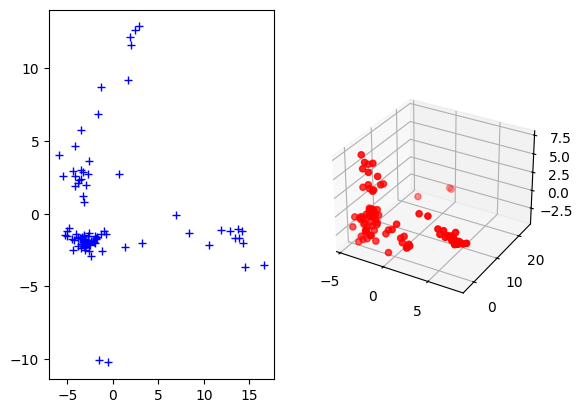

In [174]:
fig = pl.figure(1)
ax1 = fig.add_subplot(121)
ax1.plot(xs[:, 0], xs[:, 1], "+b", label="Source samples")
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(xt[:, 0], xt[:, 1], xt[:, 2], color="r")
pl.show()

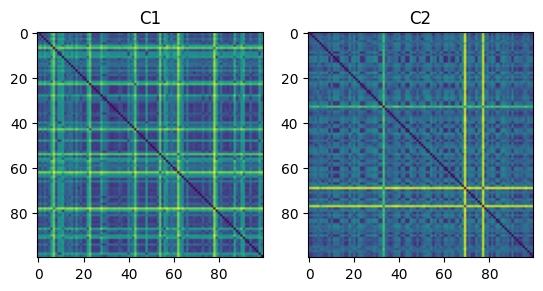

In [175]:
C1 = sp.spatial.distance.cdist(xs, xs)
C2 = sp.spatial.distance.cdist(xt, xt)

C1 /= C1.max()
C2 /= C2.max()

pl.figure(2)
pl.subplot(121)
pl.imshow(C1)
pl.title("C1")

pl.subplot(122)
pl.imshow(C2)
pl.title("C2")

pl.show()

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|6.206054e-02|0.000000e+00|0.000000e+00
    1|2.299049e-02|1.699400e+00|3.907005e-02
    2|2.299049e-02|0.000000e+00|0.000000e+00
It.  |Err         
-------------------
    0|2.730434e-02|


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


   10|6.986871e-03|
   20|6.129270e-04|
   30|2.121303e-04|
   40|4.816870e-05|
   50|2.438909e-05|
   60|3.260193e-05|
   70|1.008845e-05|
   80|2.890783e-05|
   90|1.459600e-04|
  100|4.005896e-05|
  110|6.300465e-05|
  120|5.079148e-04|
  130|1.115917e-04|
  140|1.426331e-06|
  150|1.974103e-05|
  160|1.257621e-06|
  170|1.849968e-08|
  180|4.502570e-09|
  190|9.200232e-09|
It.  |Err         
-------------------
  200|4.055260e-08|
  210|6.840418e-08|
  220|7.748775e-08|
  230|7.655846e-08|
  240|7.683245e-08|
  250|1.232906e-07|
  260|4.198050e-07|
  270|3.123468e-06|
  280|6.433925e-05|
  290|7.608237e-05|
  300|6.161641e-07|
  310|8.124364e-07|
  320|5.326523e-07|
  330|2.040320e-07|
  340|5.892234e-08|
  350|1.624127e-08|
  360|4.817730e-09|
  370|1.517006e-09|
  380|4.954116e-10|
It.  |Err         
-------------------
    0|2.730434e-02|
   10|7.621754e-03|
   20|1.928535e-03|
   30|8.980234e-05|
   40|1.034434e-05|
   50|1.499984e-06|
   60|2.318207e-07|
   70|3.905776e-08|
  

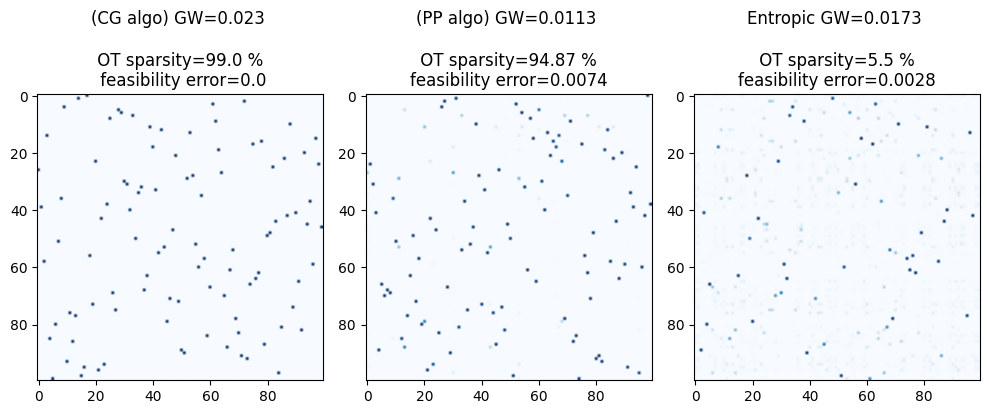

In [176]:
p = ot.unif(n_samples)
q = ot.unif(n_samples)

# Conditional Gradient algorithm
gw0, log0 = ot.gromov.gromov_wasserstein(
    C1, C2, p, q, "square_loss", verbose=True, log=True
)

# Proximal Point algorithm with Kullback-Leibler as proximal operator
gw, log = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=5e-4, solver="PPA", log=True, verbose=True
)

# Projected Gradient algorithm with entropic regularization
gwe, loge = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=5e-4, solver="PGD", log=True, verbose=True
)

print(
    "Gromov-Wasserstein distance estimated with Conditional Gradient solver: "
    + str(log0["gw_dist"])
)
print(
    "Gromov-Wasserstein distance estimated with Proximal Point solver: "
    + str(log["gw_dist"])
)
print(
    "Entropic Gromov-Wasserstein distance estimated with Projected Gradient solver: "
    + str(loge["gw_dist"])
)

# compute OT sparsity level
gw0_sparsity = 100 * (gw0 == 0.0).astype(np.float64).sum() / (n_samples**2)
gw_sparsity = 100 * (gw == 0.0).astype(np.float64).sum() / (n_samples**2)
gwe_sparsity = 100 * (gwe == 0.0).astype(np.float64).sum() / (n_samples**2)

# Methods using Sinkhorn projections tend to produce feasibility errors on the
# marginal constraints

err0 = np.linalg.norm(gw0.sum(1) - p) + np.linalg.norm(gw0.sum(0) - q)
err = np.linalg.norm(gw.sum(1) - p) + np.linalg.norm(gw.sum(0) - q)
erre = np.linalg.norm(gwe.sum(1) - p) + np.linalg.norm(gwe.sum(0) - q)

pl.figure(3, (10, 6))
cmap = "Blues"
fontsize = 12
pl.subplot(131)
pl.imshow(gw0, cmap=cmap)
pl.title(
    "(CG algo) GW=%s \n  \n OT sparsity=%s \n feasibility error=%s"
    % (
        np.round(log0["gw_dist"], 4),
        str(np.round(gw0_sparsity, 2)) + " %",
        np.round(np.round(err0, 4)),
    ),
    fontsize=fontsize,
)

pl.subplot(132)
pl.imshow(gw, cmap=cmap)
pl.title(
    "(PP algo) GW=%s \n  \n OT sparsity=%s \nfeasibility error=%s"
    % (
        np.round(log["gw_dist"], 4),
        str(np.round(gw_sparsity, 2)) + " %",
        np.round(err, 4),
    ),
    fontsize=fontsize,
)

pl.subplot(133)
pl.imshow(gwe, cmap=cmap)
pl.title(
    "Entropic GW=%s \n  \n OT sparsity=%s \nfeasibility error=%s"
    % (
        np.round(loge["gw_dist"], 4),
        str(np.round(gwe_sparsity, 2)) + " %",
        np.round(erre, 4),
    ),
    fontsize=fontsize,
)

pl.tight_layout()
pl.show()

In [177]:
np.sum(gw)

np.float64(1.0)

### Next steps
1. Identify predicted human cell for each pig cell
2. Label cell types
3. Visualize / quantify whether cell types were correctly paired
4. Repeat with two mice and two humans

In [183]:
gw = gw_mvh1[1]

In [184]:
# identify predicted human cell for each pig cell
argmax_arr = np.argmax(gw, axis=1) # row sum

In [185]:
cell_pairs = []
cell_type_pairs = []
for col in range(len(argmax_arr)):
    mouse_cell_num = col
    human_cell_num = int(argmax_arr[col])
    cell_pairs.append((mouse_cell_num, human_cell_num))
    cell_type_pairs.append((tsp1_balanced.obs['cell_type'][mouse_cell_num], tsp2_balanced.obs['cell_type'][human_cell_num]))

/tmp/ipykernel_3557275/188182592.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cell_type_pairs.append((tsp1_balanced.obs['cell_type'][mouse_cell_num], tsp2_balanced.obs['cell_type'][human_cell_num]))


In [186]:
cell_type_pairs

[('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer cell'),
 ('B cell', 'natural killer 

In [187]:
np.mean([1 if cell_type_pairs[i][0] == cell_type_pairs[i][1] else 0 for i in range(len(cell_type_pairs))])

np.float64(0.32666666666666666)

In [145]:
len(cell_type_pairs)

250

In [104]:
mouse_small.obs.head(10)

,n_genes,leiden,cell_type
AATGTCAGTAACTTCT-1,3070,0,B cell
ATCACATAGAGCATGG-1,1828,0,B cell
AGTCTGGGTGTCTAGG-1,4326,0,B cell
AAGTGTCGTATGTTGA-1,899,0,B cell
GCCTGCTTCCCCACTA-1,5306,0,B cell
ACTGTTGAGCAGCGTT-1,2691,5,T cell
ATTCGCTTCATACAAC-1,5585,4,classical monocyte
GGACCGACAGTGGCAG-1,338,7,Megakaryocyte
GCTACAGGTATCCGTC-1,2774,0,B cell
ATTGAGAAGCGTTACA-1,3264,6,natural killer cell


In [35]:
human_small.obs.iloc[81,:]

n_genes    1136
leiden        6
Name: TCGATTTCACAAGCCC-1, dtype: object

pig 7 (naive T) -> human 0 (naive T) 
pig 1 (NK) -> human 8 (NK)
pig 2 (unclear) -> human 6 (myeloid)
pig 2 (unclear) -> human 
pig 7 (naive T) -> human 0 (naive T)
pig 0 (naive T) -> human 14 (cDC2)
pig 17 (NK) -> human 8 (NK)

In [36]:
np.array([[0, 1], [0, 5]])

array([[0, 1],
       [0, 5]])

In [37]:
np.sum(np.array([[0, 1], [0, 5]]),axis=1)

array([1, 5])

In [186]:
cell_pairs[:5]

[(0, 98), (1, 31), (2, 27), (3, 52), (4, 26)]

In [187]:
mouse_small.obs.head(5)

,n_genes,leiden,cell_types
AATGTCAGTAACTTCT-1,3070,0,B
ATCACATAGAGCATGG-1,1828,0,B
AGTCTGGGTGTCTAGG-1,4326,0,B
AAGTGTCGTATGTTGA-1,899,0,B
GCCTGCTTCCCCACTA-1,5306,0,B


In [189]:
human_small.obs.iloc[98]

n_genes       1476
leiden           2
cell_types    T/NK
Name: GTCACTCTCATTATCC-1, dtype: object